<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/Python-Notebook-Banners/Code_challenge.png"  style="display: block; margin-left: auto; margin-right: auto;";/>
</div>

## Integrated Project: Understanding the yield
© ExploreAI Academy

In this coding challenge, we will apply all of the skills we learned in regression.

⚠️ **Note that this code challenge is graded and will contribute to your overall marks for this module. Submit this notebook for grading. Note that the names of the functions are different in this notebook. Transfer the code in your notebook to this submission notebook**

### Instructions

- **Do not add or remove cells in this notebook. Do not edit or remove the `### START FUNCTION` or `### END FUNCTION` comments. Do not add any code outside of the functions you are required to edit. Doing any of this will lead to a mark of 0%!**

- Answer the questions according to the specifications provided.

- Use the given cell in each question to see if your function matches the expected outputs.

- Do not hard-code answers to the questions.

- The use of StackOverflow, Google, and other online tools is permitted. However, copying a fellow student's code is not permissible and is considered a breach of the Honour code. Doing this will result in a mark of 0%.

# Introduction to simple linear regression

Simple linear regression is a fundamental statistical method used to quantify the relationship between two variables. It allows us to predict an outcome (dependent variable) based on the value of one predictor (independent variable). In this challenge, we will apply simple linear regression to understand how different environmental factors affect the standardised yield of crops.

Our insights will not only help local farmers maximise their harvests but also contribute to the sustainable agriculture practices in Maji Ndogo.



# Initial data exploration

Before we sow the seeds of our regression model, we need to get to know our soil – the dataset. This dataset was developed through extensive agricultural surveys conducted at farms across Maji Ndogo. It contains various factors that might influence a farm's crop yield, from the elevation of the fields to the average temperature they bask in.

Spend some time looking at the data dictionary and start thinking about what could be influencing our crop yield.

# Data dictionary

**1. Geographic features**

- **Field_ID:** A unique identifier for each field (BigInt).

- **Elevation:** The elevation of the field above sea level in metres (Float).

- **Latitude:** Geographical latitude of the field in degrees (Float). (DUMMY VARIABLE- the simulation might have created a relationship)

- **Longitude:** Geographical longitude of the field in degrees (Float). (DUMMY VARIABLE- the simulation might have created a relationship)

- **Location:** Province the field is in (Text).

- **Slope:** The slope of the land in the field (Float).

**2. Weather features**

- **Rainfall:** Amount of rainfall in the area in mm (Float).

- **Min_temperature_C:** Average minimum temperature recorded in Celsius (Float).(DUMMY VARIABLE)

- **Max_temperature_C:** Average maximum temperature recorded in Celsius (Float).(DUMMY VARIABLE)

- **Ave_temps:** Average temperature in Celcius (Float).

**3. Soil and crop features**

- **Soil_fertility:** A measure of soil fertility where 0 is infertile soil, and 1 is very fertile soil (Float).

- **Soil_type:** Type of soil present in the field (Text).

- **pH:** pH level of the soil, which is a measure of how acidic/basic the soil is (Float).

**4. Farm management features**

- **Field_ID:** Corresponding field identifier (BigInt).

- **Pollution_level:** Level of pollution in the area where 0 is unpolluted and 1 is very polluted (Float).

- **Plot_size:** Size of the plot in the field (Ha) (Float). (DUMMY VARIABLE)

- **Chosen_crop:** Type of crop chosen for cultivation (Text).

- **Annual_yield:** Annual yield from the field (Float). This is the total output of the field. The field size and type of crop will affect the Annual Yield (DUMMY VARIABLE - Removed)

<br>

**5. Target variable**
- **Standard_yield:** Standardised yield expected from the field, normalised per crop (Float). This is independent of field size, or crop type. Multiplying this number by the field size, and average crop yield will give the Annual_Yield.

---

Let's import our database again, like we did last time. We won't use the weather data so it is commented out.

**Important:** Ensure that `data_ingestion.py` file and the `field_data_processor.py` files are stored in the same folder as your notebook, otherwise the data import will fail. The links to the files are below:

[Download files here](https://github.com/Explore-AI/Public-Data/raw/master/Maji_Ndogo/modules.zip)


In [5]:
# Read the database, and clean the data using the processing modules we built.

import re
import numpy as np
import pandas as pd
from field_data_processor import FieldDataProcessor
# from weather_data_processor import WeatherDataProcessor
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

query =     """
            SELECT *
            FROM geographic_features
            LEFT JOIN weather_features USING (Field_ID)
            LEFT JOIN soil_and_crop_features USING (Field_ID)
            LEFT JOIN farm_management_features USING (Field_ID)
            """

config_params = {
    "sql_query": """
            SELECT *
            FROM geographic_features
            LEFT JOIN weather_features USING (Field_ID)
            LEFT JOIN soil_and_crop_features USING (Field_ID)
            LEFT JOIN farm_management_features USING (Field_ID)
            """,
    "db_path": 'sqlite:///Maji_Ndogo_farm_survey_small.db',
    "columns_to_rename": {'Annual_yield': 'Crop_type', 'Crop_type': 'Annual_yield'},
    "values_to_rename": {'cassaval': 'cassava', 'wheatn': 'wheat', 'teaa': 'tea'},
    "weather_csv_path": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_station_data.csv",
    "weather_mapping_csv": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_data_field_mapping.csv",
    "regex_patterns" : {
            'Rainfall': r'(\d+(\.\d+)?)\s?mm',
            'Temperature': r'(\d+(\.\d+)?)\s?C',
            'Pollution_level': r'=\s*(-?\d+(\.\d+)?)|Pollution at \s*(-?\d+(\.\d+)?)'
            },
}
# Ignoring the field data for now.
field_processor = FieldDataProcessor(config_params, query)
field_processor.process()
field_df = field_processor.df

# We're not going to use the weather data this time, so we'll ignore it.
# weather_processor = WeatherDataProcessor(config_params)
# weather_processor.process()
# weather_df = weather_processor.weather_df

dataset = field_df.drop("Weather_station", axis=1)

2024-11-18 18:19:24,949 - field_data_processor.FieldDataProcessor - INFO - Sucessfully loaded data.
2024-11-18 18:19:24,955 - field_data_processor.FieldDataProcessor - INFO - Swapped columns: Annual_yield with Crop_type


In [6]:
len(dataset.columns)

18

In [7]:
dataset

,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,8.526684e-02,1.3,0.751354,cassava,0.577964
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,3.996838e-01,2.2,1.069865,cassava,0.486302
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,3.580286e-01,3.4,2.208801,tea,0.649647
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,2.866871e-01,2.4,1.277635,cassava,0.532348
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,4.319027e-02,1.5,0.832614,wheat,0.555076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5649,11472,681.36145,-7.358371,-6.254369,Rural_Akatsi,16.213196,885.7,-4.3,33.4,14.55,0.61,Sandy,5.741063,3.286828e-01,1.1,0.609930,potato,0.554482
5650,19660,667.02120,-3.154559,-4.475046,Rural_Kilimani,2.397553,501.1,-4.8,32.1,13.65,0.54,Sandy,5.445833,1.602583e-01,8.7,3.812289,maize,0.438194
5651,41296,670.77900,-14.472861,-6.110221,Rural_Hawassa,7.636470,1586.6,-3.8,33.4,14.80,0.64,Volcanic,5.385873,8.221326e-09,2.1,1.681629,tea,0.800776
5652,33090,429.48840,-14.653089,-6.984116,Rural_Hawassa,13.944720,1272.2,-6.2,34.6,14.20,0.63,Silt,5.562508,6.917245e-10,1.3,0.659874,cassava,0.507595


Before diving into our analysis, it's crucial to ensure the integrity of our dataset and that the data is still as we expect it to be.

In [8]:
# Validate the data
# !pip install pytest

dataset.to_csv('sampled_field_df.csv', index=False)

!pytest validate_data.py -v

import os# Define the file paths
field_csv_path = 'sampled_field_df.csv'

# Delete sampled_field_df.csv if it exists
if os.path.exists(field_csv_path):
    os.remove(field_csv_path)
    print(f"Deleted {field_csv_path}")
else:
    print(f"{field_csv_path} does not exist.")

======================================= test session starts ========================================
platform linux -- Python 3.10.12, pytest-8.3.3, pluggy-1.5.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/drive/MyDrive/2024/GoogleCloud /DataScience/Regression Code Challenge
plugins: typeguard-4.4.1, anyio-3.7.1
collected 4 items                                                                                  

validate_data.py::test_read_field_dataframe_shape PASSED                                     [ 25%]
validate_data.py::test_field_dataframe_columns PASSED                                        [ 50%]
validate_data.py::test_field_dataframe_non_negative_elevation PASSED                         [ 75%]
validate_data.py::test_crop_types_are_valid PASSED                                           [100%]

======================================== 4 passed in 1.20s =========================================
Deleted sampled_field_df.csv


# Analysis

## Challenge 1: Visualising the relationship

With our data ready and loaded, it's time to start exploring.

Our goal is to determine whether any of the features in our dataset are influencing the `Standard_yield` of a farm. If we can figure out what these relationships are, then we can use them to start predicting what future yields will be, based on these features.

For this analysis, we want to find whether any features have a linear relationship with `Standard_yield` so that we can fit a linear regression model to the data. This is important because if we try and fit a linear regression model to non-linear data, our predictions won't be good.

Any of the features could have an impact on the `Standard_yield`. Let's begin with `Ave_temps`, the average temperature of the region, and its relationship to `Standard_yield`.

Let's start with the basics: a scatter plot.


**⚙️ Your task:**

 1. Generate a scatter plot to visualise the relationship between `Ave_temps` and `Standard_yield`.
 2. Reflect on the scatter plot. Does it suggest a linear relationship, or is the story more complex?

**Note:**
- Use `matplotlib` to create the scatter plot.

In [9]:
import matplotlib.pyplot as plt

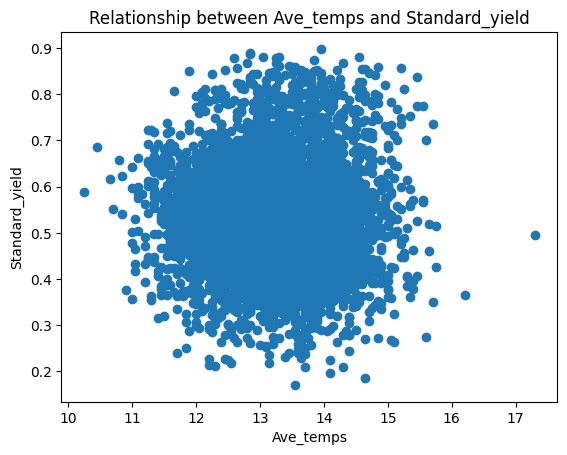

In [10]:
# Insert code to draw a scatter plot here
plt.scatter(dataset["Ave_temps"], dataset["Standard_yield"])
plt.title("Relationship between Ave_temps and Standard_yield")
plt.xlabel("Ave_temps")
plt.ylabel("Standard_yield")
plt.show()

Now, let's write a function to calculate the Pearson correlation coefficient.

**⚙️ Your task:**

Create a function named `get_correlation` that:
1. Takes a DataFrame and the names of the columns we want to determine the correlation for as parameters (`Ave_temps` and `Standard_yield`).
2. Calculates the Pearson correlation coefficient between these two columns to quantify their linear relationship.
4. Returns the Pearson correlation coefficient.

**Note:**
- Use `scipy` to calculate the Pearson correlation coefficient.
- Ensure your function returns the Pearson correlation coefficient as a float.

In [11]:
from scipy.stats import pearsonr

In [12]:
### START FUNCTION
def get_correlation(df, col1, col2):
  """
  Calculate the Pearson correlation coefficient between two columns in a DataFrame.

  Parameters:
  df (DataFrame): Input DataFrame
  col1 (str): Name of the first column
  col2 (str): Name of the second column

  Returns:
  Float: Pearson correlation coefficient
  """
  # Ensure columns exist in the DataFrame
  if col1 not in df.columns or col2 not in df.columns:
    raise ValueError("One or both columns do not exist in the DataFrame")

  # Calculate Pearson correlation coefficient using scipy
  corr_coef = pearsonr(df[col1], df[col2])[0]
  return corr_coef
### END FUNCTION


Input:

In [13]:
correlation = get_correlation(dataset,'Ave_temps','Standard_yield')
print("Pearson correlation coefficient:", correlation)

Pearson correlation coefficient: 0.006785950289020186


Expected output
```
Correlation: 0.006785950289020164
```

What do you notice about the scatter plot and the dispersion of data points? It's essential to visualise our data first; if the data doesn't follow a linear pattern, then a linear regression model may fail to accurately capture the underlying relationship. The correlation also seems extremly low, what does this tell us?

Let's write down some of our observations:

  - ✍️ Your notes here
- The pearson correlation coefficient measures the linear relationship between two variables. It ranges from -1 to +1:

-1: A perfect negative correlation (as one variable increases, the other decreases).
0: No linear correlation (the variables don't show a linear relationship).
+1: A perfect positive correlation (as one variable increases, the other also increases).
Interpretation for 'Ave_temps' and 'Standard_yield':

A correlation coefficient of 0.006785950289020186, which is very close to 0, indicates that there's almost no linear relationship between Ave_temps (average temperature) and Standard_yield (standardized yield) in your dataset. This means that changes in average temperature do not reliably predict changes in standardized yield in a linear way.

Scatter Plot:

From our observation, the scatter plot also supports this finding – the data points are dispersed and don't follow a clear linear pattern. This visual representation reinforces the weak correlation indicated by the Pearson coefficient.

In summary:

Both the Pearson correlation coefficient and the scatter plot suggest that there is a very weak or no linear relationship between average temperature and standardized yield in your dataset. This implies that a linear regression model using Ave_temps to predict Standard_yield would likely have poor predictive power.

Reasoning:

Linear regression relies on linear relationships: Linear regression models work best when there's a clear linear trend in the data. Since there's little to no linear relationship here, it's unlikely to be a good fit for this specific relationship.
Correlation doesn't equal causation: It's important to remember that even if there were a strong correlation, it wouldn't necessarily mean that changes in Ave_temps cause changes in Standard_yield. Other factors could be influencing the yield.


## Challenge 2: A breath of fresh data: Pollution as a predictor


It's time to shift our gaze from the warmth of the sun to the haze of pollution. Could the levels of pollution, a concern for farmers and environmentalists alike, be an indicator of our yields?

Let's begin by fitting a simple linear regression model, to try and capture the linear relationship between these columns.

**⚙️ Your task:**

Create a function named `fit_linear_regression_model` that:
1. Takes in a DataFrame and the names of the `Pollution_level` and `Standard_yield` columns.
2. Fits a linear regression model to the data.
3. Returns the model, the model predictions and the actual y-values.

**Note:**
- Use `LinearRegression` from `sklearn` to fit the model.

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
### START FUNCTION
def fit_linear_regression_model(df, pollution_col, yield_col):

    """
    Fits a linear regression model to the data.

    Args:
    df (pandas DataFrame): The input DataFrame.
    pollution_col (str): The name of the pollution column.
    yield_col (str): The name of the yield column.

    Returns:
    tuple: A tuple containing the fitted model, predictions, and actual y-values.
    """
    # Create the linear regression model
    model = LinearRegression()

    # Extract the features (X) and target (y)
    X = df[[pollution_col]]
    y = df[yield_col]

    # Fit the model
    model.fit(X, y)

    # Make predictions
    predictions = model.predict(X)

    return model, predictions, y
### END FUNCTION


Input:

In [16]:
model, predictions, y_values = fit_linear_regression_model(dataset, 'Pollution_level', 'Standard_yield')
print(f"Model: {model}")
print(f"Predictions: {predictions}")
print(f"Actual Y-Values: {y_values}")

Model: LinearRegression()
Predictions: [0.5540956  0.50920888 0.51515565 ... 0.56626844 0.56626844 0.52896886]
Actual Y-Values: 0       0.577964
1       0.486302
2       0.649647
3       0.532348
4       0.555076
          ...   
5649    0.554482
5650    0.438194
5651    0.800776
5652    0.507595
5653    0.453064
Name: Standard_yield, Length: 5654, dtype: float64


Expected output:
```
- Model: an instance of the LinearRegression class.
- Predictions: a NumPy array of predicted values.
- y: a Pandas Series with the actual target values used for training.
```

Linear regression models only work well if our data is in fact linear. So, lets create a scatter plot to visualise the relationship between pollution and crop yields. In addition to this, let's use the predictions from the model we fit to add the line of best fit to our scatter plot.

**⚙️ Your task:**

1. Generate a scatter plot to visualise the effect that pollution has on standard yield.
2. Draw the line of best fit

**Hint:**

You can use this line of code to draw the regression line on the plot:
`plt.plot(X, predictions, color='red', label='Regression line')`

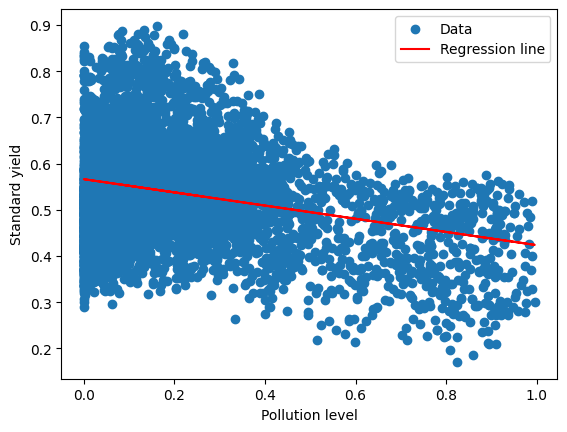

In [17]:
X = dataset[['Pollution_level']]
y = dataset['Standard_yield']

# Add code to draw the scatter plot and the regression line
plt.scatter(X, y, label="Data")
plt.plot(X, predictions, color='red', label='Regression line')
plt.legend()
plt.xlabel("Pollution level")
plt.ylabel("Standard yield")
plt.show()

Now, use the get_correlation() function that we defined earlier to test the correlation between `Pollution_level` and `Standard_yield`.

In [18]:
Pollution_correlation = get_correlation(dataset,'Pollution_level','Standard_yield')
print("Pearson correlation coefficient:", Pollution_correlation)

Pearson correlation coefficient: -0.2857609646210545


Expected output
```
Correlation: -0.2857609646210543
```

Reflect on the difference between this plot and correlation and the previous one with the average temperature. Is the relationship between pollution and yield more linear?

  - ✍️ Your notes here
  -The correlation of -0.2857... and the negative linear relationship shown in the scatter plot tell us that there's a tendency for standard yield to decrease as pollution levels increase.
- However, the relationship is not very strong, meaning there are likely other factors influencing standard yield besides pollution.

- __Compared to the previous one of  average temperature__
- Strength of Relationship: The relationship between pollution level and standard yield is stronger than the relationship between average temperature and standard yield. This is evident in the higher magnitude of the correlation coefficient for pollution (-0.2857...) compared to average temperature (0.0067...).

- Direction of Relationship: Pollution level has a __negative relationship__ with standard yield (as pollution increases, yield tends to decrease), whereas average temperature shows __no clear direction__ in its relationship with standard yield


We can also gain a better understanding of our model by examining the slope and intercept.

**⚙️ Your task:**

Create a function named `get_slope_intercept` that:
1. Inputs the `model` we fitted and calculates the slope and intercept of the line of best fit.
2. Return the slope and intercept as a tuple.


In [19]:
### START FUNCTION
def get_slope_intercept(model):
    """
    Calculates the slope and intercept of the line of best fit.

    Args:
    model: The fitted linear regression model.

    Returns:
    tuple: A tuple containing the slope and intercept.
    """
    slope = model.coef_[0]  # Access the slope from the model's coefficients
    intercept = model.intercept_  # Access the intercept

    return slope, intercept
### END FUNCTION

Input:

In [20]:
slope, intercept = get_slope_intercept(model)
print("Slope:", slope)
print("Intercept:", intercept)

Slope: -0.1427617720986607
Intercept: 0.566268441539338


Expected output:
```
Slope: -0.1427617720986604
Intercept: 0.5662684415393379
```


What does the slope tell us about the strength of the relationship between pollution and yield? Also, what can we learn from the y-intercept?

  - ✍️ Your notes here

  - __Slope:__

- __Strength and Direction:__ The slope represents the change in the dependent variable (standard yield) for a one-unit change in the independent variable (pollution level). In this case, a negative slope of -0.1427... indicates that as pollution levels increase by one unit, the standard yield is predicted to decrease by approximately 0.1427 units.
__Strength of Relationship:__ The magnitude of the slope provides some indication of the strength of the relationship. While the __slope isn't very large,__ it's not close to zero either, suggesting there is a __moderate negative linear relationship__ between pollution and yield. __However, this doesn't tell us the full story about strength.__ It is more meaningful to consider in conjunction with other metrics like R-Squared.

- __Y-intercept:__

- __Baseline Yield:__ The y-intercept represents the predicted value of the dependent variable (standard yield) when the independent variable (pollution level) is zero. In this context, __it suggests that when pollution levels are at their lowest (or theoretically absent), the predicted standard yield is around 0.5662... units__

## Challenge 3: The haze clears: Evaluating pollution's predictive power

When we look at the scatterplots of `Standard_yield` with `Ave_temps` and `Pollution_level`, it appears that pollution level might have a more linear relationship.  This means that we could potentially use a simple linear regression model to make predictions about the yield of a farm based on its pollution level. However, before we do this we need to further assess the strength of the linear relationship between `Pollution_level` and `Standard_yield`.

Let's assess our model's performance using R-squared, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

**⚙️ Your task:**

Create a function named `calculate_evaluation_metrics` that:
1. Takes the predictions and y-values from our fitted model as input.
2. Calculates and returns the R-squared, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) of the model's performance.

**Note:**
1. Calculate the model's performance metrics using the entire dataset.
2. Return the evaluation metrics as a tuple in the order: R-squared, MAE, MSE, RMSE.

In [21]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [25]:
### START FUNCTION
def calculate_evaluation_metrics(predictions, y_values):
    """
    Calculates evaluation metrics for a regression model.

    Args:
    predictions: The model's predictions.
    y_values: The actual target values.

    Returns:
    tuple: A tuple containing R-squared, MAE, MSE, and RMSE.
    """
    R_squared = r2_score(y_values, predictions)
    MAE = mean_absolute_error(y_values, predictions)
    MSE = mean_squared_error(y_values, predictions)
    RMSE= np.sqrt(MSE)  # or use mean_squared_error(y_values, predictions, squared=False)

    return R_squared, MAE, MSE, RMSE

### END FUNCTION

Input:

In [23]:
evaluation_metrics = calculate_evaluation_metrics(predictions, y_values)
print(f"Evaluation Metrics:\nR-squared: {evaluation_metrics[0]}\nMAE: {evaluation_metrics[1]}\nMSE: {evaluation_metrics[2]}\nRMSE: {evaluation_metrics[3]}")

Evaluation Metrics:
R-squared: 0.08165932890115568
MAE: 0.08554642090904993
MSE: 0.011477732254034844
RMSE: 0.10713417873878926


Expected output:

A tuple containing numerical values for R-squared, MAE, MSE, and RMSE (give or take 0.0001):

```python
R-squared: 0.08165932890115546
MAE: 0.08554642090904992
MSE: 0.011477732254034848
RMSE: 0.10713417873878928

```

Think about what these metrics tell us about our model's accuracy and reliability. Write down your observations:

  - ✍️ Your notes here
- R-squared (0.08165932890115568):

- Low Explained Variance: R-squared represents the proportion of variance in the target variable (standard yield) that is explained by the model. A value of 0.0816... means that the model explains only about 8.16% of the variability in standard yield. This is quite low, suggesting that the model's predictions are not very accurate or that other factors significantly influence standard yield.

- Mean Absolute Error (MAE) (0.08554642090904993):

 - Average Prediction Error: MAE is the average absolute difference between the predicted and actual values. In this case, the MAE of 0.0855... means that, on average, the model's predictions are off by about 0.0855 units. This value should be interpreted in the context of the target variable's scale. If standard yield typically ranges from 0 to 1, then an MAE of 0.0855 might be considered relatively small.
- Mean Squared Error (MSE) (0.011477732254034844):

 - Squared Prediction Error: MSE is the average squared difference between the predicted and actual values. It gives more weight to larger errors. The MSE of 0.0114... is difficult to interpret directly, but it's useful for comparing different models.
- Root Mean Squared Error (RMSE) (0.10713417873878926):

 - Error in Target Units: RMSE is the square root of the MSE and is in the same units as the target variable. In this case, an RMSE of 0.1071... means that, on average, the model's predictions are off by about 0.1071 units of standard yield. This is slightly higher than the MAE, indicating that there might be some larger errors that are influencing the RMSE.

- Overall Interpretation:

- Limited Accuracy and Reliability: The low R-squared value suggests that the model's predictions are not very accurate and that it doesn't capture a significant portion of the variation in standard yield.
- Moderate Error: While the MAE and RMSE are relatively small (depending on the scale of standard yield), they still indicate a degree of error in the model's predictions



## Challenge 4: The dividing line: Train-test split in action

As we delve deeper into the relationship between `Pollution_level` and `Standard_yield`, we must ensure our model is not merely memorising the data but truly understanding it. This brings us to the pivotal technique of Train-Test Split.

**The importance of train-test split**

Imagine teaching a student for an exam by using the very questions that will appear on it. They might score perfectly, but does it mean they've truly learned? Similarly, a model might perform exceptionally on the data it was trained on, but the real test of knowledge comes from unseen data. This is where the train-test split comes in, allowing us to assess our model's generalisation capabilities by training on one subset of data and testing on another.

**Your task**

Create a function named `data_train_test_split` that:
1. Takes in the DataFrame and the two columns we want to model the relationship between (`Pollution_level` and `Standard_yield`).
2. Separates it into features (`X`) based on `Pollution_level` and the target (`y`) based on `Standard_yield`.
3. Splits the data into training and testing sets using an 80-20 split and sets `random_state = 42` for reproducibility.
4.  Returns a tuple containing: `X_train` and `X_test`, which are DataFrames containing features for training and testing, respectively, along with `y_train` and `y_test`, which are Series representing subsets of the original DataFrame's target variable for training and testing.

**Note:**
- Use `train_test_split` from `sklearn.model_selection` to split the data.
- Train a linear regression model on the training set using `LinearRegression` from `sklearn.linear_model`.
- If the random state is not set to `42` the code will not be marked correctly.

In [26]:
from sklearn.model_selection import train_test_split

In [32]:
### START FUNCTION
def data_train_test_split(df, pollution_col, yield_col):
    """
    Splits the data into training and testing sets.

    Args:
    df: The input DataFrame.
    pollution_col: The name of the pollution column.
    yield_col: The name of the yield column.

    Returns:
    tuple: A tuple containing X_train, X_test, y_train, y_test.
    """
    # Extract features (X) and target (y)
    X = df[[pollution_col]]
    y = df[yield_col]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    return X_train, X_test, y_train, y_test
### END FUNCTION

Input:

In [30]:
X_train, X_test, y_train, y_test = data_train_test_split(dataset, 'Pollution_level', 'Standard_yield')
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train shape: (4523, 1), X_test shape: (1131, 1)
y_train shape: (4523,), y_test shape: (1131,)


Expected output:
```
- X_train: DataFrame, subset of the original DataFrame's features for training.
- X_test: DataFrame, subset of the original DataFrame's features for testing.
- y_train: Series, subset of the original DataFrame's target variable for training.
- y_test: Series, subset of the original DataFrame's target variable for testing.
```

Now lets fit a linear regression model to the data.

**Your task**

Create a function named `train_split_linear_regression_model()` that:
1. Takes `X_train`, `X_test`, `y_train`, `y_test` as input (the results from the `data_train_test_split()` function).
2. Trains a simple linear regression model on the training set.
3. Uses the testing set to make predictions.
4. Returns a tuple containing: the model, the predictions and y_test (the actual y values in the testing set values) .

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
### START FUNCTION
def train_split_linear_regression_model(X_train, X_test, y_train, y_test):
    """
    Trains a linear regression model and makes predictions on the test set.

    Args:
    X_train: The training features.
    X_test: The testing features.
    y_train: The training target.
    y_test: The testing target.

    Returns:
    tuple: A tuple containing the model, predictions, and y_test.
    """
    # Create and train the model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Make predictions on the test set
    predictions_test = model.predict(X_test)

    return model, predictions_test, y_test
### END FUNCTION

Input:

In [35]:
train_test_model, predictions_test, y_test = train_split_linear_regression_model(X_train, X_test, y_train, y_test)
print(f"Train-Test Model: {train_test_model}")
print(f"Test Predictions: {predictions_test}")
print(f"Test Actual Y-Values: {y_test}")

Train-Test Model: LinearRegression()
Test Predictions: [0.56412206 0.56167249 0.55638552 ... 0.53129108 0.53868457 0.56431394]
Test Actual Y-Values: 4816    0.446290
5096    0.650771
4706    0.531284
1499    0.516429
3544    0.555724
          ...   
3982    0.540212
4952    0.670387
1071    0.353658
718     0.535224
4103    0.470315
Name: Standard_yield, Length: 1131, dtype: float64


Expected output:
```
- Model: an instance of the LinearRegression class.
- Predictions: a NumPy array of predicted values.
- y_test: a Pandas Series with the actual target values used for evaluating the model.
```

Now, let's evaluate our use our train-test model by determining R-squared, MAE, MSE, and RMSE.

**⚙️ Your task:**

1. Use the `calculate_evaluation_metrics` function (defined in Challenge 3) to calculate the R-squared, MAE, MSE, and RMSE.
2. The function should return a tuple containing the evaluation metrics (R-squared, MAE, MSE, and RMSE).

**Note:**

- Ensure to use the test set to calculate the evaluation metrics.

In [38]:
# Add code to calculate the R-squared, MAE, MSE, and RMSE
R_squared, MAE, MSE, RMSE = calculate_evaluation_metrics(predictions_test, y_test)

print(f"R-squared: {R_squared}")
print(f"MAE: {MAE}")
print(f"MSE: {MSE}")
print(f"RMSE: {RMSE}")

R-squared: 0.08065722992150859
MAE: 0.087949421197475
MSE: 0.012250634233355654
RMSE: 0.11068258324305434


Expected output:

A tuple containing numerical values for R-squared, MAE, MSE, and RMSE (give or take 0.0001):

```python
R-squared: 0.08065722992150859
MAE:  0.08794942119747501
MSE: 0.012250634233355654
RMSE: 0.11068258324305434

```

Reflect on the difference between these metics and the metrics we obtained from the previous model (that was not split into training and testings sets). Why do you think the fit is worse now? And, why should we choose the worse option? (Reflect on the course material if these answers to these questions are not clear.)

  - ✍️ Your notes here

- Comparison:

- R-squared: The R-squared value is slightly higher for the model trained and tested on the entire dataset (0.0816...) compared to the train-test split model (0.0806...). This is because the model trained on the entire dataset has effectively memorized the data and is better at fitting to the noise and fluctuations present in the data. As a result the R-squared value might seem inflated and does not reflect the true predictive performance on unseen data. The train-test split model, on the other hand, provides a more realistic estimate of the model's generalization capabilities.

- MAE: The MAE is slightly lower for the model trained and tested on the entire dataset (0.0855...) compared to the train-test split model (0.0879...). This is again likely due to the overfitting of the model trained on the entire dataset. It has essentially learned the training data too well, including its noise, which leads to lower apparent error on the same data. This is dangerous, however, as the MAE might be much higher when applied to unseen data.

- MSE and RMSE: Similar to MAE, the MSE and RMSE are slightly lower for the model trained and tested on the entire dataset compared to the train-test split model. This further supports the observation of overfitting in the model trained on the entire dataset. These metrics are more sensitive to larger errors, so the overfitting effect is more pronounced in them

## Challenge 5: Diagnosing model fit through residual analysis

From our analysis, it seems as though neither `Ave_temps` or `Pollution_level` have a strong linear fit with `Standard_yield`. However, even if we had obtained good results from our evaluation metrics, there are still other crucial assumptions we need to verify to ensure our model is well-fitted. Residual analysis plays a pivotal role in diagnosing the fit of linear regression models, helping us understand whether the assumptions of linearity, independence, and homoscedasticity (constant variance) of residuals are met.

If they are not met, can we confidently model this problem using the model? And why?

  - ✍️ Your notes here

First, let's create a histogram.

**⚙️ Your task:**

1. Calucate the residuals of our train test model (difference between `y_test` and `predictions_test`)
2. Plot these residuals as a histogram to assess their distribution and identify any patterns.

In [39]:
import matplotlib.pyplot as plt

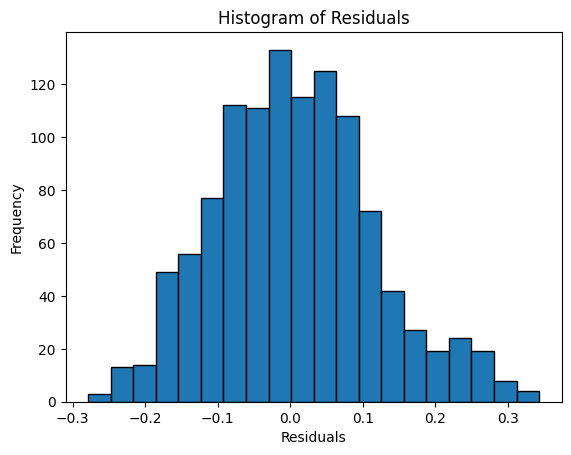

In [43]:
#  Add code to create a scatter plot of residuals against the predicted values
residuals = y_test - predictions_test # calculating the residuals

#  Add code to create a histogram of residuals
plt.hist(residuals, bins=20, edgecolor='black')  # Adjust 'bins' for desired granularity
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

What does the histogram tell us about our data:

1. Examine the shape of the histogram. What does the distribution of residuals tell us about the normality of the data? Consider whether the residuals appear to be symmetrically distributed around zero.

    - ✍️ Your notes here
     - The residuals are evenly distributed around zero

2. Compare the tails of the histogram to a normal distribution. Are there signs of heavy tails or skewness that could affect the reliability of the regression model's predictions?

    - ✍️ Your notes here
    -slightly skewed to the right

3. Assess the centering of the histogram around the zero line. How does this central tendency reflect on the bias of the model's predictions?

    - ✍️ Your notes here
    -The model exihibits some bias


Now, let's create a scatter plot of these residuals against the predicted values.

**⚙️ Your task:**

1. Create a scatter plot of the residuals against the predicted values - `predictions_test` should be on the x-axis and the `residuals` on the y-axis.

**Note:**

- A horizontal line can be added at y=0 to make it easier to see if the residuals are evenly distributed around zero by adding this line of code:
`plt.axhline(y=0, color='r', linestyle='--')`


In [ ]:
#  Add code to create a scatter plot of residuals against the predicted values
plt.scatter(predictions_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

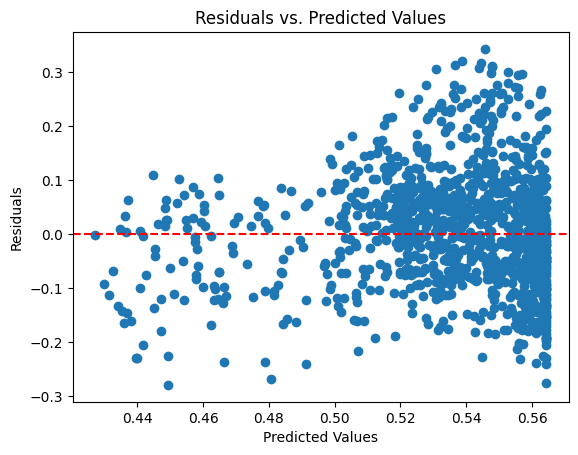

In [45]:
#  Add code to create a scatter plot of residuals against the predicted values
plt.scatter(predictions_test, residuals)
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--')  # Add horizontal line at y=0
plt.show()

Relfect on what the scatter plot tells us about our data and the fit of the model:

1. Analyse the scatter plot for any apparent patterns or structures in the data. What does this suggest about the appropriateness of the linear regression model for the dataset?

    - ✍️ Your notes here
    - The spread or dispersion of the
errors is not consistent. This means that our model's predictions aren't   accurate and
 therefore not reliable.

2. Inspect the plot for signs of heteroscedasticity. How does the spread of residuals change as the predicted values increase? What might this imply about the constant variance assumption in linear regression?

    - ✍️ Your notes here
      - The spread or dispersion of the
errors is not consistent. As the predicted values increase, the residuals form a cone shape.

3. Identify whether the residuals are evenly scattered above and below the zero line across the range of predicted values. What can this tell us about the model's performance in terms of bias and prediction accuracy?

    - ✍️ Your notes here
    - The residuals are not evenlly scattered above and below the zero line across the range of predicted values.

    Bias: Unevenly scattered residuals can indicate bias in the model's predictions. For example, if the residuals tend to be positive for lower predicted values and negative for higher predicted values, it suggests that the model is systematically underestimating lower values and overestimating higher values. This bias can lead to inaccurate predictions, especially at the extremes of the predicted value range.

Prediction Accuracy: The presence of heteroscedasticity violates one of the assumptions of linear regression, which assumes that the errors have constant variance. When this assumption is violated, the model's estimates of the regression coefficients might be less efficient or biased, which can affect the accuracy of predictions.

Reliability of Inferences: Heteroscedasticity can also affect the reliability of statistical inferences drawn from the model, such as hypothesis tests and confidence intervals. These inferences might be misleading if the errors are not homoscedastic.

Consequences:

Limited Predictive Power: If the model is biased and has unevenly scattered residuals, its predictive power might be limited, particularly for certain ranges of predicted values.
Incorrect Inferences: Inferences about the relationship between the variables might be inaccurate due to the violation of the homoscedasticity assumption.

4. Look for outliers or clusters of points that deviate significantly from the majority. How might these points influence the overall fit of the model?

    - ✍️ Your notes here


Our final task is to examine the mean and standard deviation of the residuals, which provide further insights into the model's performance.

**⚙️ Your task:**

Create a function named `calculate_residuals_statistics` that:
1. Uses the `predictions_test` and `y_test` (obtained from Challenge 4) to calculate the residuals.
2. Calculates the mean and standard deviation of the residuals.

**Note:**

- Use `numpy` for the mean and standard deviation.

In [46]:
import numpy as np

In [47]:
### START FUNCTION
def calculate_residuals_statistics(predictions, y_test):
    """
    Calculates the mean and standard deviation of the residuals.

    Args:
    predictions: The model's predictions on the test set.
    y_test: The actual values for the test set.

    Returns:
    tuple: A tuple containing the mean and standard deviation of the residuals.
    """
    residuals = y_test - predictions
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)

    return mean_residual, std_residual
### END FUNCTION

Input:

In [48]:
mean_residual, std_residual = calculate_residuals_statistics(predictions_test, y_test)
print(f"Mean: {mean_residual}\nStandard deviation: {std_residual}")

Mean: 0.00585802319232171
Standard deviation: 0.11052745268770955


Expected output:
```
Mean: 0.0058580231923217015
Standard deviation: 0.11052745268770957
```

What does the mean of the residuals tell us about the bias in our predictions? How does a mean close to zero reflect on our model's accuracy?

- ✍️ Your notes here
- Bias in Predictions: The mean of the residuals provides an indication of the bias in the model's predictions. Ideally, the mean of the residuals should be close to zero, indicating that the model's predictions are, on average, unbiased.
- Mean Close to Zero: In your case, the mean of the residuals is very close to zero (0.0058...). This suggests that your model's predictions are largely unbiased. This means the model is not systematically overestimating or underestimating the target variable. This is generally a good indication for the overall accuracy of the model.

What does the standard deviation of the residuals indicate about the variability of our predictions? Why is it important for this value to be relatively low?

 - ✍️ Your notes here

- Variability of Predictions: The standard deviation of the residuals indicates the variability or spread of the errors made by the model. It represents how much the individual predictions are likely to deviate from the true values.
- Importance of Low Standard Deviation: A lower standard deviation of residuals is desirable because it means that the model's predictions are more precise and have less variability. This gives us more confidence in the accuracy of the predictions. A larger standard deviation would show that the model's predictions are not reliable since the error rate would be greater, with a wider range of inaccuracy.


- The standard deviation of the residuals (0.1105...) might be considered relatively moderate (depending on the scale of your target variable). However, efforts to reduce it further could improve the model's overall precision and reliability. This could potentially involve exploring different model types, adding more relevant predictors, or addressing any outliers or non-linearity in the data.


What are the potential consequences of a high standard deviation of residuals on the reliability of the model's predictions? How might this affect our confidence in the model's estimates?

- ✍️ Your notes here

- Consequences of High Standard Deviation: A high standard deviation of residuals implies that the model's predictions are less reliable and have a wider range of potential errors. This would reduce our confidence in the model's estimates because the predictions are more likely to be far off from the actual values.

## Conclusion

Linear regression, for all its strengths, assumes a straightforward relationship between the predictor and the outcome. Yet, the natural world seldom adheres to such simplicity. Factors influencing crop yields in Maji Ndogo—be it temperature, rainfall, or pollution—interact in complex, often nonlinear ways. Our initial model with `Ave_temps` hinted at this complexity, suggesting that the effect of the average temperature on yields might follow a more intricate pattern than a straight line can depict (or no pattern at all).

Our yield also depends on more than just the pollution or the temperature, it depends on many of the factors. From our EDA we could see that. We also saw that not all crops are affected equally by pollution or temperature, so we could simplify our model if we remove the influence of the different crops. Once your submission is done, as a challenge to yourself, try to split the data again by crop type (with a loop) and use the functions you created to loop over all of the crop types and print out your metrics.

Compare them, and discuss your results with your colleagues. Is there a crop type that is affected by pollution more than other crop types?

As we dive deeper into regression, it's crucial to remember that with each model comes a new perspective. Just as a farmer selects the tool that best suits the task at hand, so must we choose our models with intention and insight. Exploring beyond linear regression opens up new vistas of understanding, allowing us to capture the richness of relationships within our data.

In the fields of Maji Ndogo and beyond, countless stories await. It's up to us, with curiosity as our guide and an ever-expanding array of models at our disposal, to uncover them.

#  

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/ExploreAI_logos/EAI_Blue_Dark.png"  style="width:200px";/>
</div>